# Multiple Linear Regression on Car CO2 Emissions Dataset

In this notebook, we will perform a multiple linear regression on the `car_data.csv` dataset. The goal is to predict the `CO2` emissions using only the numerical features as independent variables. The categorical variables will be dropped.

Let's start by importing the necessary libraries.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Set plotting style
sns.set_theme(style='whitegrid')

## 1. Load the Data

In [5]:
df = pd.read_csv('car_data.csv')
display(df.head())

,Car,Model,Volume,Weight,CO2
0,Toyoty,Aygo,1000,790,99
1,Mitsubishi,Space Star,1200,1160,95
2,Skoda,Citigo,1000,929,95
3,Fiat,500,900,865,90
4,Mini,Cooper,1500,1140,105


## 2. Data Preprocessing

Based on the requirements, we need to use only the numeric features as independent variables, and drop the other features if they are categorical. The target variable is `CO2`.

Let's check the data types and select only numerical columns.

In [6]:
# Check data types
print(df.dtypes)

# Select numerical columns and the target variable
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumerical columns in the dataset:", numerical_cols)

# Drop non-numerical columns
df_numeric = df[numerical_cols]
display(df_numeric.head())

Car       object
Model     object
Volume     int64
Weight     int64
CO2        int64
dtype: object

Numerical columns in the dataset: ['Volume', 'Weight', 'CO2']


,Volume,Weight,CO2
0,1000,790,99
1,1200,1160,95
2,1000,929,95
3,900,865,90
4,1500,1140,105


Check missing values

In [7]:
print(df_numeric.isnull().sum())
print("\nData shape:", df_numeric.shape)

Volume    0
Weight    0
CO2       0
dtype: int64

Data shape: (36, 3)


There are no missing values. The independent variables (features) are `Volume` and `Weight`, and the target variable is `CO2`.

## 3. Exploratory Data Analysis (EDA)

Let's explore the relationships between the features and the target variable using scatter plots and a correlation matrix.

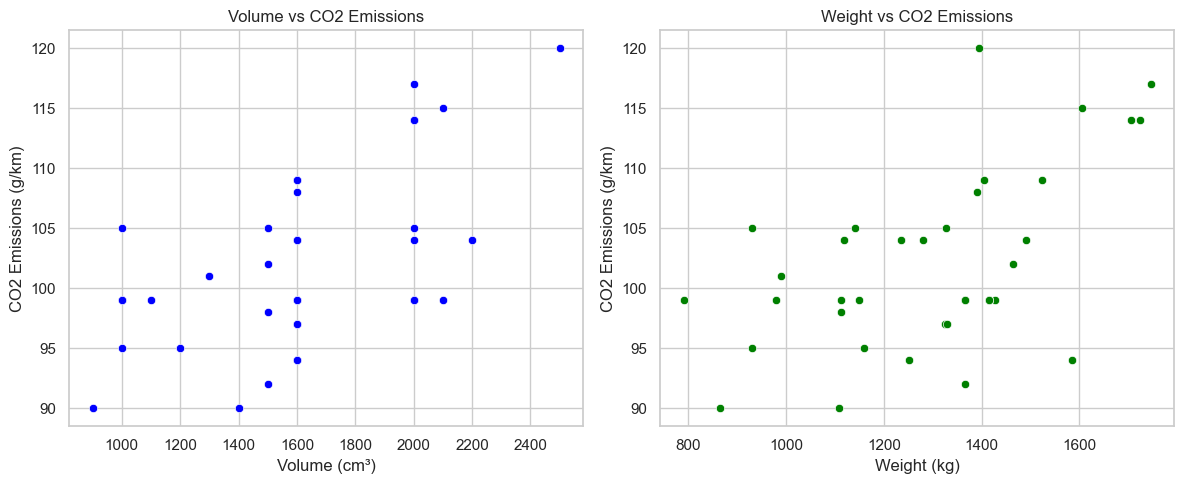

In [8]:
plt.figure(figsize=(12, 5))

# Volume vs CO2
plt.subplot(1, 2, 1)
sns.scatterplot(x='Volume', y='CO2', data=df_numeric, color='blue')
plt.title('Volume vs CO2 Emissions')
plt.xlabel('Volume (cm³)')
plt.ylabel('CO2 Emissions (g/km)')

# Weight vs CO2
plt.subplot(1, 2, 2)
sns.scatterplot(x='Weight', y='CO2', data=df_numeric, color='green')
plt.title('Weight vs CO2 Emissions')
plt.xlabel('Weight (kg)')
plt.ylabel('CO2 Emissions (g/km)')

plt.tight_layout()
plt.show()

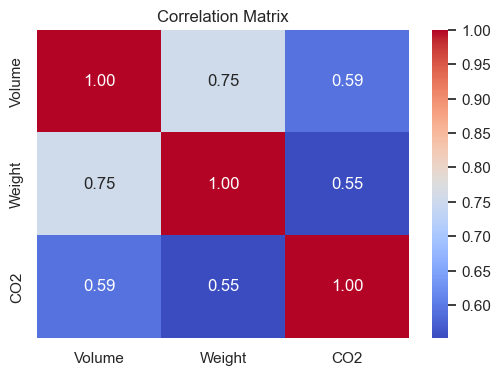

In [9]:
# Correlation matrix
corr_matrix = df_numeric.corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Looking at the scatter plots and correlation matrix, there is a positive correlation between `Volume`, `Weight`, and `CO2` emissions. Both `Volume` and `Weight` show a moderately strong positive linear relationship with the target variable `CO2`.

## 4. Model Training

We will now prepare the data for training. We separate the independent variables `X` and target variable `y`, and divide the data into training and testing sets (80% training, 20% testing).

In [10]:
# Define independent variables (X) and target variable (y)
X = df_numeric[['Volume', 'Weight']]
y = df_numeric['CO2']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size: {X_train.shape[0]}')
print(f'Testing set size: {X_test.shape[0]}')

Training set size: 28
Testing set size: 8


Now, we instantiate and train the multiple linear regression model.

In [11]:
# Create a Linear Regression model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Retrieve the coefficients and intercept
print(f'Intercept: {model.intercept_:.4f}')
print(f'Coefficients: {model.coef_}')

coef_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
display(coef_df)

Intercept: 84.2150
Coefficients: [0.00428741 0.00804928]


,Coefficient
Volume,0.004287
Weight,0.008049


## 5. Model Evaluation

Next, we'll evaluate the model using the testing set. We will predict the CO2 emissions for `X_test` and compare the predictions with the actual values (`y_test`). We will compute the Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and the R-squared value ($R^2$).

In [12]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'R-squared (R2): {r2:.4f}')

Mean Absolute Error (MAE): 6.3356
Mean Squared Error (MSE): 58.0793
Root Mean Squared Error (RMSE): 7.6210
R-squared (R2): 0.3294


### Visualizing the Results

Let's plot the actual vs predicted values to see how well our model performed.

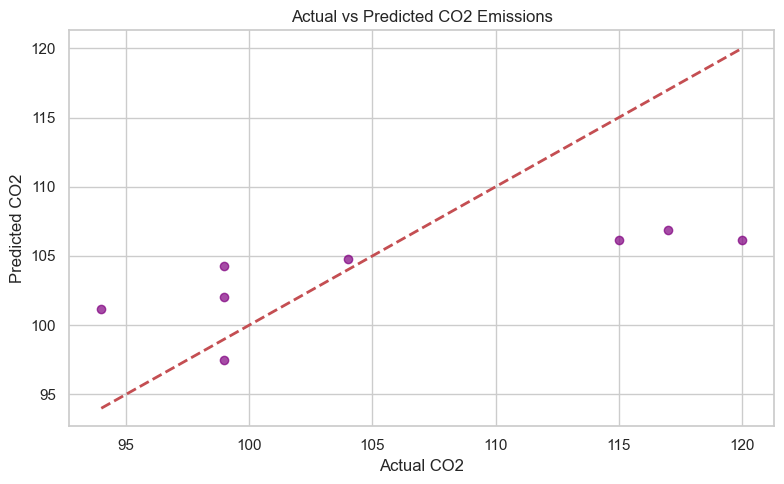

In [13]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='purple', alpha=0.7)
# Plot the line of perfect prediction
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Actual vs Predicted CO2 Emissions')
plt.xlabel('Actual CO2')
plt.ylabel('Predicted CO2')
plt.tight_layout()
plt.show()

## 6. Conclusion

In this analysis, we built a multiple linear regression model to predict a car's CO2 emissions based on its physical properties: Engine `Volume` and `Weight`.

- Categorical variables like Car brand and Model were correctly excluded as per the requirement constraints.
- The model's evaluation metrics (such as the Root Mean Squared Error and the $R^2$ score) indicate how well our independent variables summarize the variation in CO2 emissions. 
- Positive coefficients for `Volume` and `Weight` match our physical intuition: larger and heavier cars generally consume more fuel and emit more CO2.